# Homework09

Exercises to practice dimensionality reduction with PCA

## Goals

- Add unsupervised pre-processing to our ML flow: encode -> normalize -> pre-process -> train -> evaluate
- Build an intuition for PCA and when/how to use it
- Understand the benefits of dimensionality reduction

### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework.

In [5]:
!sudo wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py
!sudo wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/image_utils.py
!sudo wget -q https://github.com/PSAM-5020-2026S-A/Homework07/raw/main/Homework07_utils.pyc

!sudo wget -qO- https://github.com/PSAM-5020-2026S-A/5020-utils/releases/latest/download/0801-500.tar.gz | tar xz

In [6]:
from os import listdir, path
from PIL import Image as PImage

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

from image_utils import get_pixels, make_image

from Homework07_utils import CamUtils

## PCA and Classification

Let's practice doing some more image classification with `PCA` and analyzing the results.

The dataset is the same one we used in `Homework07`. It has images from $25$ different security cameras, and our task is to separate them by camera. Some of the cameras move, some of them don't, and there are more than $1000$ images, so there's no way we want to do this by hand.

Let's start by loading the training images into a list of pixels, like we did with the `faces` dataset in class.

### Loading Data

If we look at the images in `./data/image/0801-500/train/`, we'll notice that they are named and organized in a slightly different way. They're all in the same directory and the first part of their filename specifies which camera they came from. Even though those `ids` are numbers, they're not sequential, so we'll use some helper functions to extract a unique `label` from their filenames.

This is exactly what the `OrdinalEncoder` class does, but since we only have to encode this one column, we'll do it by hand while we read the files in.

In [7]:
# this creates a list of all the files in a given directory, that end in .jpg
train_files = [f for f in listdir("./data/image/0801-500/train") if f.endswith(".jpg")]

In [8]:
# TODO: check and see what is inside the list here
print(len(train_files))
print(train_files[:3])

250
['25-23.jpg', '21-28.jpg', '25-69.jpg']


Now we'll read the image pixels and extract their labels. `CamUtils.get_label()` is the helper function we'll use to "encode" and return a label id based on the filename.

In [9]:
pixel_data = []
label_data = []

for fname in train_files:
  label = CamUtils.get_label(fname)
  img = PImage.open(path.join("./data/image/0801-500/train", fname))
  pixel_data.append(get_pixels(img))
  label_data.append(label)

In [10]:
# TODO: check if labels got extracted correctly by looking at 
# the first few items of the label list and the filename list

#print(pixel_data[:3])
print(label_data[:3])

[20, 16, 20]


Like in `Homework07`, the labels and the filenames won't match exactly since labels start at $0$ and the filenames start at $01$ and skip some numbers.

We can open some images from pixels, just to make sure we loaded them correctly:

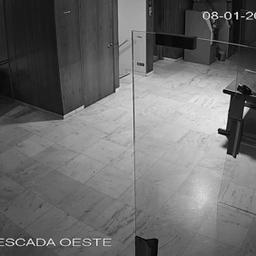

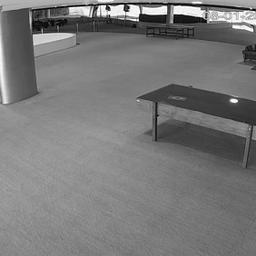

In [11]:
display(make_image(pixel_data[0]))
display(make_image(pixel_data[10]))

### PCA

Create a `DataFrame` called `cam_pca_df` by running `PCA` on the list of pixel data, just like we did in class, and then append a `label` column to it, just like we did in Homework07 with: `train_df["label"] = label_data`.

You can change how many components to extract from the images later, but for this first run just use $10$ components so we can compare classification with $10$ `PCA` components to the classification with $10$ random features from `Homework07`.  Make sure to confirm how much of the `variance` is preserved by this transformation.

In [12]:
# TODO: run PCA, get DataFrame
# TODO: add "label" column
# TODO: print variance
# TODO: take a look at the first 5 rows

cam_pca = PCA(n_components=11).set_output(transform="pandas") 
cam_pca_df = cam_pca.fit_transform(pixel_data)

cam_pca_df["label"] = label_data

print(sum(cam_pca.explained_variance_ratio_))

print(cam_pca_df.head(5))



0.8010405910635379
          pca0         pca1         pca2         pca3         pca4  \
0  1794.608495  -635.082795  2757.507574 -7765.019266  2225.487703   
1  2113.341233   580.857320  6920.800018  2766.322405 -2271.065965   
2  7031.032954 -2135.261689  -741.983790 -3747.551558   894.202503   
3  3806.710420 -2697.584968  5286.902807  -732.751044 -4771.198546   
4  1401.392839 -6806.930232 -3191.399012  8889.745604  1720.730672   

          pca5         pca6         pca7         pca8         pca9  \
0 -3188.600049  1954.883877 -3275.628333 -4175.554966 -1463.362184   
1  1175.598350 -1682.127606 -1618.105773  3842.708219   155.543938   
2   255.333957  1190.774456 -2877.243896 -1706.092501   482.813687   
3  1967.889749 -1745.573235 -2300.493109  1927.864510  -843.844489   
4  6296.793966  3733.711716 -1665.288984 -1588.340522 -2863.546071   

         pca10  label  
0  1065.936673     20  
1  -279.507887     16  
2  -659.700223     20  
3   588.676594     23  
4  4081.855009     

### Interpretation

<span style="color:hotpink">
How many components did you keep ?<br>
Did you try different numbers ?<br>
What percent of variance is kept by this transformation?
</span>

<span style="color:hotpink;">
I ended up with 11 components after testing a lot and comparing the variances by changing the n_component = x. I ended with 11 because the variance was just about equal to 80%
</span>

### Reconstruct

Before we go run our classification, let's take a look at some reconstructed images, just to make sure they make sense.

Take a look at reconstructed versions of images $0$, $10$, and whichever other images you might have opened above.

We did this in class. It involves a `inverse_transform()` function.

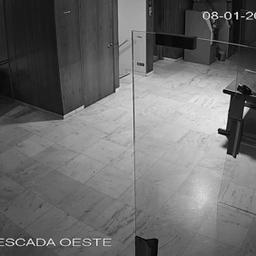

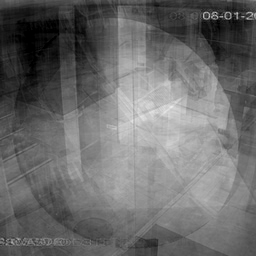

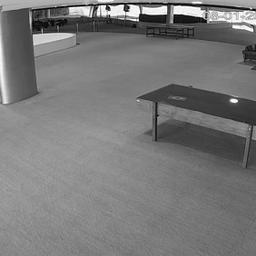

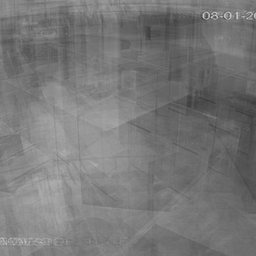

In [15]:
# TODO: reconstruct image at index 0

pca_pixels = cam_pca.inverse_transform(cam_pca_df.drop(columns=["label"]))

display(make_image(pixel_data[0]))
display(make_image(pca_pixels.loc[0]))
                                                                                       
# TODO: reconstruct image at index 10

display(make_image(pixel_data[10]))
display(make_image(pca_pixels.loc[10]))


The reconstructed images should look blurrier and noisier than the original ones, but they should still look something like the original ones.

### Classify !

Train a `RandomForestClassifier` on the `PCA` data.

Remember to separate the output feature (`label`) from the input features (`PC0`, `PC1`, etc).

In [17]:
# TODO: create a classifier

classifier = RandomForestClassifier()


# TODO: split input and output features

x = cam_pca_df.drop(columns=["label"])
y = cam_pca_df["label"]

# TODO: fit the model

classifier.fit(x, y)

# TODO: run predictions

train_predictions = classifier.predict(x)

print(train_predictions[:10])

[20 16 20 23 18  7 15  0  8  6]


### Measure Error

For the train set we could use the generic `classification_error()` function that we've used before because we have the true labels for each file, but for measuring accuracy for our `test` set classification, which has secret labels, we have to use a more specific function from the `CamUtils` class.

The function is called `classification_accuracy()` and it takes $2$ parameters, a list of filenames and the predicted labels associated with those filenames.

The result is an accuracy score ratio, between $0.0$ and $1.0$.

We can run this function on the `train` set as well:

In [18]:
# train_files is the list of files we got way up above
CamUtils.classification_accuracy(train_files, train_predictions)

1.0

### Interpretation

<span style="color:hotpink">
What does this mean?<br>
Should we expect the same result from the test dataset?<br>
Why, or why not?
</span>

<span style="color:hotpink;">

the 1.0 means 100% accurace... so all the train files I think match the train predictions.
that is good because it means it's identifying correctly. I anticipate it won't work quite as well on the test because theres new images not old ones. 

</span>

### Run on Test set

Now we'll open the image files inside the `./data/image/0801-500/test/` directory, using almost the exact same steps as we did above to create a `DataFrame` with the exception that we don't have labels for these images.

In [19]:
# TODO: create a list of files in the test/ directory

test_files = [f for f in listdir("./data/image/0801-500/test") if f.endswith(".jpg")]

# TODO: check its length and content

print(len(test_files))
print(test_files[:3])

1573
['5317520.jpg', '8312516.jpg', '16015312.jpg']


We'll use a similar loop to extract the pixel information from these images, except we don't have `label` data, just pixels.

In [20]:
test_pixel_data = []

for fname in test_files:
  img = PImage.open(path.join("./data/image/0801-500/test", fname))
  test_pixel_data.append(get_pixels(img))

Now we can run `PCA` and the `RandomForestClassifier`.

Since those are already trained, all we have to do is run their `transform()` function on the data.

In [21]:
# TODO: run PCA on test pixels, get DataFrame
#this is the same PCA that was created above, not a new one

test_pca_df = cam_pca.transform(test_pixel_data)
test_pca_df.columns = [f"pc{i}" for i in range(11)]

It's always a good idea to check the result of the `PCA` transformation by looking at the `DataFrame` and reconstructing some images.

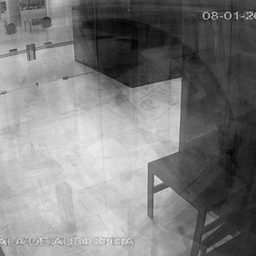

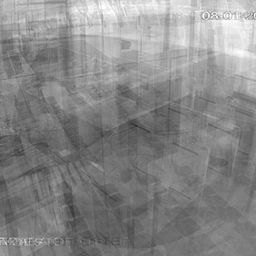

            pc0           pc1           pc2          pc3          pc4  \
0   6113.894308   3418.994315 -13442.423922 -2917.377848 -3204.303442   
1 -20727.986562 -12432.431436  -2093.258077   -54.689057  -598.942518   
2 -10396.299924   6108.238174  -3741.519314  5654.785255 -2580.174175   
3 -16827.350482   5833.596921   -182.318084 -6695.249830  2512.425893   
4   2552.109595   7585.306629  -2377.903724 -3594.719804  -770.662851   

           pc5          pc6          pc7          pc8          pc9  \
0  2249.340234 -1819.948655 -1894.336512    99.891652 -2585.019950   
1 -3802.465328  -572.202083 -2352.955890 -1533.131947  -145.506741   
2 -1694.856437 -3802.563876  -735.154099 -5568.374027  2116.825678   
3 -3313.181138  2160.140630 -2907.412803 -1039.377522 -2424.138067   
4 -1251.996476  2798.962800   809.779684  1502.250483 -1269.404346   

          pc10  
0 -2796.748285  
1  -311.952195  
2  -440.004729  
3  -620.029727  
4  3524.466504  


In [24]:
# TODO: reconstruct one or two images

test_reconstructed = cam_pca.inverse_transform(test_pca_df)

display(make_image(test_reconstructed.loc[0]))
display(make_image(test_reconstructed.loc[10]))

# TODO: take a look at the first 5 rows\
print(test_pca_df.head(5))

### Interpretation

<span style="color:hotpink"><br>
The reconstructed images from the `test` set will always be noisier than the `train` images.<br><br>
Why?<br><br>
</span>

<span style="color:hotpink;">
Test images are new and might have things that wern't seen in before in the train images. Because PCA runs too, we lose components so it gets most but not all of it. 
</span>



Run the classifier and get predicted labels. Then get its accuracy ratio is by running the `CamUtils.classification_accuracy()` function with the list of filenames and list of predictions.

In [ ]:
# TODO: run classifier. This is the same classifier already fitted on the train data above

test_pca_df.columns = x.columns
test_predictions = classifier.predict(test_pca_df)
test_accuracy = CamUtils.classification_accuracy(test_files, test_predictions)

# TODO: get accuracy

print(test_accuracy)

0.9256198347107438


### Interpretation

<span style="color:hotpink">
What's the accuracy ? How could we improve that if we wanted ?<br>
How does this compare to the classification model from <code>Homework07</code>? They can both be tuned to perform well, but how many features did we need last time in order to get an accuracy comparable to this?
</span>

<span style="color:hotpink;">
Cool!!! it's 92.5 accuracy. We can make it better maybe by giving it more components! It might just run a little slower I think. I believe in Homework07 it was 10 pixels with a pretty low accuracy and it would have needed way more pixesl or way more pixels in strategic spots to get similar accuracy. PCA is cool :0 
</span>